Data loaded successfully


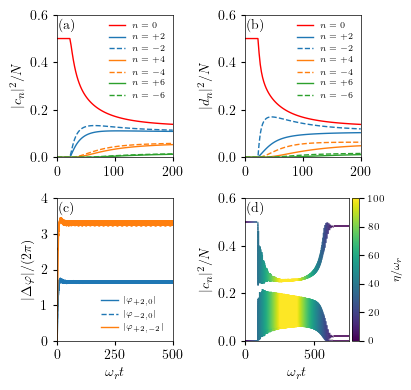

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# ============================================================
# LOAD DATA
# ============================================================
data = np.load(r"Figure_12_data.npz")

eta_scaled = data["eta_scaled"]
pop        = data["pop"]

t          = data["t"]
delta_p01  = data["delta_p01"]
delta_m01  = data["delta_m01"]
delta_pm1  = data["delta_pm1"]

c0         = data["c0"]
cp         = data["cp"]
cm         = data["cm"]
eta_vals   = data["eta_vals"]

omega_r    = data["omega_r"]
N          = data["N"]

print("Data loaded successfully")

# ============================================================
# APS STYLE
# ============================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 7,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1,
})

colors = {
    0: 'red',
    2: 'tab:blue',
    4: 'tab:orange',
    6: 'tab:green'
}

# ============================================================
# FIGURE
# ============================================================
fig, axs = plt.subplots(2, 2, figsize=(4.2, 4.0))
plt.subplots_adjust(wspace=0.55, hspace=0.35)

ax1, ax2 = axs[0]
ax3, ax4 = axs[1]

# ============================================================
# (a) c-modes
# ============================================================
labels = [r'$n = 0$', r'$n =+2$', r'$n =-2$', r'$n =+4$', r'$n =-4$', r'$n =+6$', r'$n =-6$']

for i, (idx, col) in enumerate([(0,0),(1,2),(2,2),(3,4),(4,4),(5,6),(6,6)]):
    ax1.plot(eta_scaled, pop[:, idx],
             ls='--' if i in [2,4,6] else '-',
             color=colors[col],
             label=labels[i])

ax1.legend(frameon=False, fontsize=6, loc='upper right')
ax1.set_ylabel(r'$|c_n|^2/N$')
ax1.set_xlim(0, 200)
ax1.set_ylim(0, 0.6)
ax1.text(0.02, 0.9, r'(a)', transform=ax1.transAxes)

# ============================================================
# (b) d-modes
# ============================================================
for i, (idx, col) in enumerate([(7,0),(8,2),(9,2),(10,4),(11,4),(12,6),(13,6)]):
    ax2.plot(eta_scaled, pop[:, idx],
             ls='--' if i in [2,4,6] else '-',
             color=colors[col],
             label=labels[i])

ax2.legend(frameon=False, fontsize=6, loc='upper right')
ax2.set_ylabel(r'$|d_n|^2/N$')
ax2.set_xlim(0, 200)
ax2.set_ylim(0, 0.6)
ax2.text(0.02, 0.9, r'(b)', transform=ax2.transAxes)

# ============================================================
# (c) Phase dynamics
# ============================================================
x_phase = omega_r * t

ax3.plot(x_phase, np.abs(delta_p01)/(2*np.pi), color='tab:blue',
         label=r'$|\varphi_{+2, 0}|$')

ax3.plot(x_phase, np.abs(delta_m01)/(2*np.pi), '--',
         color='tab:blue', label=r'$|\varphi_{-2, 0}|$')

ax3.plot(x_phase, np.abs(delta_pm1)/(2*np.pi),
         color='tab:orange', label=r'$|\varphi_{+2, -2}|$')

ax3.set_xlabel(r'$\omega_r t$')
ax3.set_ylabel(r'$|\Delta\varphi|/(2\pi)$')
ax3.legend(frameon=False, fontsize=6, loc='lower right')
ax3.set_xlim(0, 500)
ax3.set_ylim(0, 4)
ax3.text(0.02, 0.9, r'(c)', transform=ax3.transAxes)

# ============================================================
# (d) Ramping dynamics
# ============================================================
def colored_line(ax, x, y, c, cmap='viridis'):
    pts = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap=cmap,
                        norm=Normalize(c.min(), c.max()))
    lc.set_array(c)
    lc.set_linewidth(1.2)
    ax.add_collection(lc)
    return lc

x_ramp = omega_r * t

lc = colored_line(ax4, x_ramp, np.abs(c0)**2, eta_vals)
colored_line(ax4, x_ramp, np.abs(cp)**2, eta_vals)
colored_line(ax4, x_ramp, np.abs(cm)**2, eta_vals)

ax4.set_xlabel(r'$\omega_r t$')
ax4.set_ylabel(r'$|c_n|^2/N$')
ax4.set_xlim(0, 750)
ax4.set_ylim(0, 0.6)
ax4.text(0.02, 0.9, r'(d)', transform=ax4.transAxes)

# ============================================================
# COLORBAR
# ============================================================
cbar = fig.colorbar(lc, ax=ax4, fraction=0.08, pad=0.02)
cbar.set_label(r'$\eta/\omega_r$', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# ============================================================
# CLEAN LOOK
# ============================================================
for ax in axs.flat:
    ax.tick_params(direction='out', length=3, width=0.8)

plt.tight_layout()
plt.show()